# Inspection — Credit Signal Project EDA

**Scope.** Source of non-production code. Locks the data-quality, regime, and portfolio-constraint decisions deferred to EDA. Outputs feed `config/config.yaml` and the Data section of `README.md`.

**Sections:**
- **A** — Bond panel (decisions on universe / outliers / caps / date convention)
- **B** — FRED macro (regime classifier method + thresholds)
- **C** — Point-in-time merge sanity

**Dependencies:** `pandas`, `numpy`, `matplotlib`, `pyyaml`, `fredapi`.

In [136]:
from pathlib import Path
import yaml, numpy as np, pandas as pd, matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
CONFIG_PATH  = PROJECT_ROOT / "config"   / "config.yaml"
BOND_CSV     = PROJECT_ROOT / "raw_data" / "USHY_INDEX_20260301_part_1.csv"

with open(CONFIG_PATH) as f:
    config = yaml.safe_load(f) or {}

print(f"Project root: {PROJECT_ROOT}")
print(f"Bond CSV exists: {BOND_CSV.exists()}")
print(f"Config keys: {list(config.keys())}")

Project root: c:\Users\Sam\Desktop\Invesco Project\project
Bond CSV exists: True
Config keys: ['fred', 'dates', 'data', 'signal', 'regime', 'portfolio', 'logging']


In [137]:
bonds = pd.read_csv(BOND_CSV)
bonds["Date"] = pd.to_datetime(bonds["Date"], format="%m/%d/%Y")
print(f"Shape: {bonds.shape}  |  Dates: {bonds.Date.min().date()} -> {bonds.Date.max().date()}  ({bonds.Date.nunique()} months)")
print(f"CUSIPs: {bonds.Cusip.nunique():,}  |  Tickers: {bonds.Ticker.nunique():,}")

Shape: (218657, 18)  |  Dates: 2010-01-01 -> 2018-12-01  (108 months)
CUSIPs: 6,696  |  Tickers: 2,541


## A — Bond Panel

Months: 108 found, 0 missing


Text(0, 0.5, 'count')

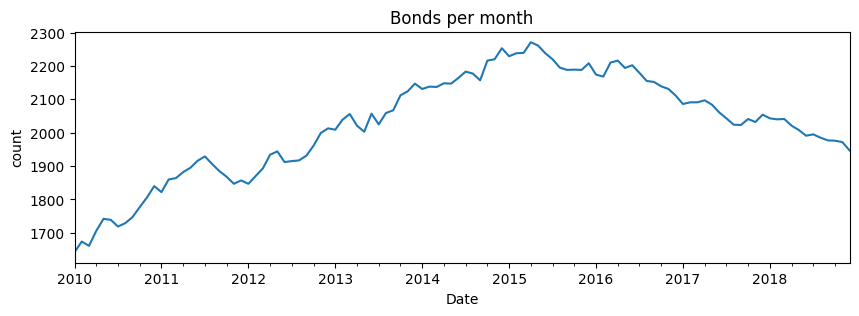

In [138]:
# A.1 — Monthly completeness
dates = sorted(bonds.Date.unique())
missing = sorted(set(pd.date_range(dates[0], dates[-1], freq="MS")) - set(dates))
print(f"Months: {len(dates)} found, {len(missing)} missing")
bonds.groupby("Date").size().plot(figsize=(10, 3), title="Bonds per month")
plt.ylabel("count")

In [139]:
# A.2 — Schema, nulls, Maturity_Date sentinel
print(bonds.dtypes)
print("\nNulls:")
print(bonds.isnull().sum()[bonds.isnull().sum() > 0])
print(f"\nMaturity_Date '1/1/1900' share: {(bonds.Maturity_Date == '1/1/1900').mean()*100:.2f}%")

Date                   datetime64[ns]
Cusip                          object
ISIN                           object
Class1                         object
Class2                         object
Class3                         object
Ticker                         object
Eff_Rating_Group               object
Index_Rating_Number             int64
Maturity_Date                  object
Years_To_Maturity             float64
DTS                           float64
OAS                           float64
OAD                           float64
OASD                          float64
Yield_To_Worst                float64
Total_Return_MTD              float64
Excess_Return_MTD             float64
dtype: object

Nulls:
DTS     9
OASD    9
dtype: int64

Maturity_Date '1/1/1900' share: 99.11%


In [140]:
# A.3 — Categorical fields
print(bonds.Eff_Rating_Group.value_counts().sort_index())
print(f"\nFallen angels (BBB/A/AA): {bonds.Eff_Rating_Group.isin(['AA','A','BBB']).sum():,}")
print(f"D_NR: {(bonds.Eff_Rating_Group == 'D_NR').sum():,}")
print(f"\nGovernment_Related: {(bonds.Class1 == 'Government_Related').sum()}")
print(f"Agency: {(bonds.Class2 == 'Agency').sum()}")

Eff_Rating_Group
A           9
AA          3
B       88653
BB      82542
BBB       679
CCC     45321
D_NR     1450
Name: count, dtype: int64

Fallen angels (BBB/A/AA): 691
D_NR: 1,450

Government_Related: 8
Agency: 8


              OAS        OASD         DTS  Excess_Return_MTD  \
count  218657.000  218648.000  218648.000         218657.000   
mean      570.611       3.964      20.869              0.378   
std      1034.355       2.385      18.902              4.848   
min     -5057.400       0.000       0.000            -97.990   
0.1%     -117.454       0.000       0.000            -39.271   
1%          0.000       0.000       0.000            -13.550   
5%        165.200       0.540       1.320             -4.632   
50%       413.300       3.800      16.470              0.430   
95%      1338.120       8.540      56.140              5.020   
99%      3255.728      11.880      91.725             12.514   
99.9%    9485.342      14.844     145.778             40.700   
max    185285.300      18.420     319.870            237.450   

       Years_To_Maturity  
count         218657.000  
mean               6.372  
std                4.708  
min                0.920  
0.1%               0.920  
1%   

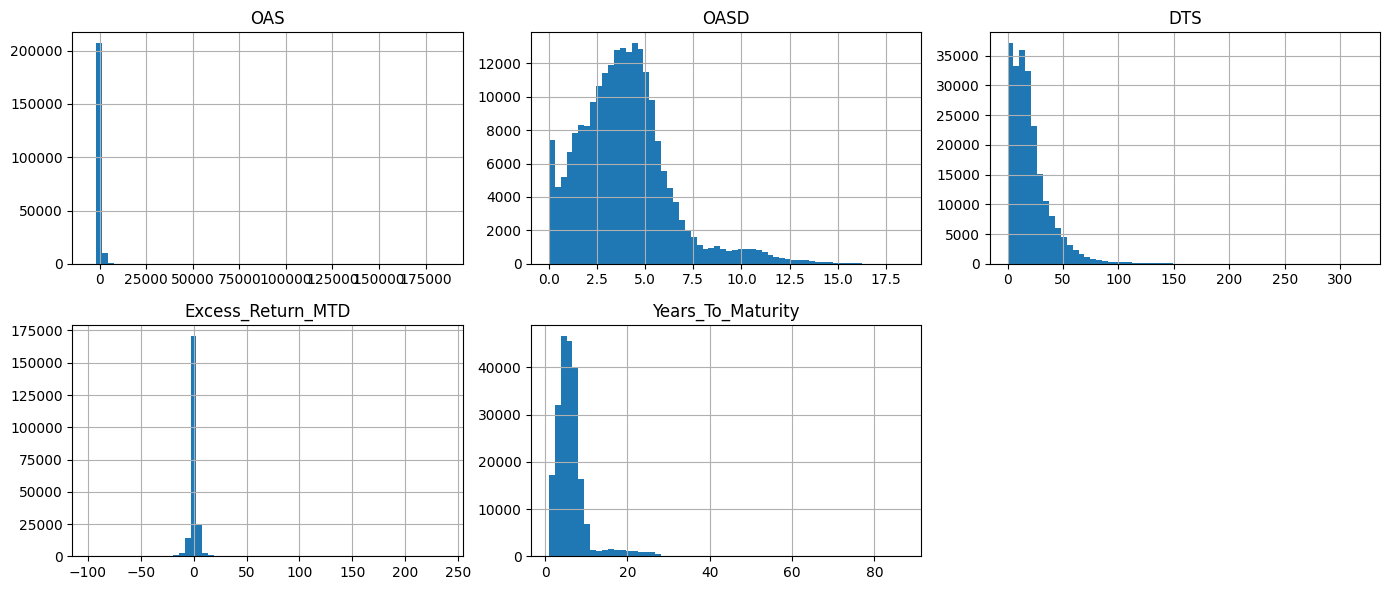

In [141]:
# A.4 — Numeric distributions
cols = ["OAS", "OASD", "DTS", "Excess_Return_MTD", "Years_To_Maturity"]
print(bonds[cols].describe(percentiles=[.001, .01, .05, .5, .95, .99, .999]).round(3))

print("\nEdge cases:")
for k, v in {
    "OAS < 0":     (bonds.OAS < 0).sum(),
    "OAS > 10K":   (bonds.OAS > 10000).sum(),
    "OASD == 0":   (bonds.OASD == 0).sum(),
    "DTS == 0":    (bonds.DTS == 0).sum(),
    "|ER| > 20":   (bonds.Excess_Return_MTD.abs() > 20).sum(),
    "YTM > 30y":   (bonds.Years_To_Maturity > 30).sum(),
}.items():
    print(f"  {k:14s} {v:>8,}")

fig, axes = plt.subplots(2, 3, figsize=(14, 6))
for ax, col in zip(axes.flat, cols):
    bonds[col].hist(bins=60, ax=ax)
    ax.set_title(col)
axes.flat[-1].axis("off")
plt.tight_layout()

In [142]:
# A.5 — Issuer concentration
per_im = bonds.groupby(["Date", "Ticker"]).size()
print("Bonds per issuer per month:")
print(per_im.describe(percentiles=[.5, .9, .95, .99, .999]).round(1))
print(f"\nTop 10 issuers (total obs):")
print(bonds.Ticker.value_counts().head(10))
print(f"\nMean unique issuers/month: {bonds.groupby('Date').Ticker.nunique().mean():.0f}")

Bonds per issuer per month:
count    98887.0
mean         2.2
std          2.4
min          1.0
50%          1.0
90%          4.0
95%          7.0
99%         13.0
99.9%       22.0
max         39.0
dtype: float64

Top 10 issuers (total obs):
Ticker
HCA       2083
ALLY      1622
APOLLO    1461
OTC       1430
FTR       1420
MGM       1190
AES       1136
CTL       1129
SOFTBK    1100
CCMO      1093
Name: count, dtype: int64

Mean unique issuers/month: 916


Class3
Consumer_Cyclical                    18.38
Communications                       13.31
Energy                               13.31
Consumer_Non_Cyclical                11.41
Basic_Industry                        9.74
Capital_Goods                         9.16
Technology                            5.65
Electric                              3.53
Finance_Companies                     3.21
Transportation                        2.40
Banking                               2.19
Other_Industrial                      2.10
Natural_Gas                           1.66
Insurance                             1.48
Other_Financial                       0.99
REITs                                 0.94
Brokerage_Assetmanagers_Exchanges     0.50
Other_Utility                         0.02
Government_Owned__No_Guarantee        0.00
dtype: float64


Text(0, 0.5, 'share')

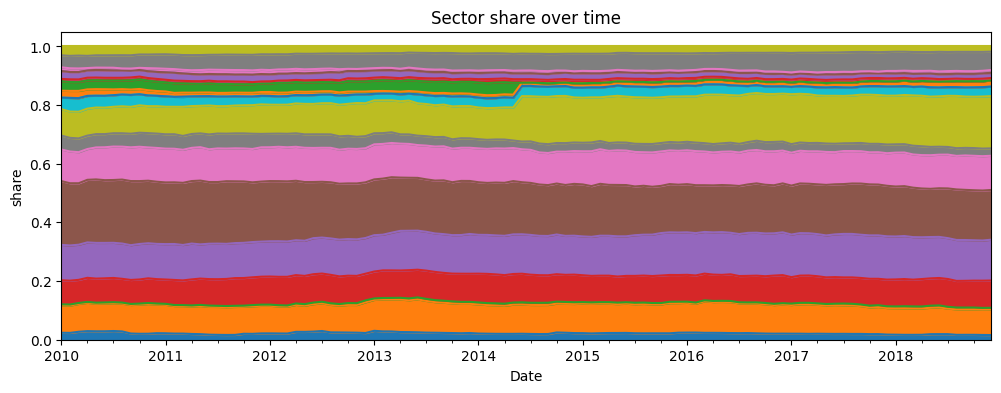

In [143]:
# A.6 — Sector concentration over time
sector_pct = bonds.groupby(["Date", "Class3"]).size().unstack(fill_value=0)
sector_pct = sector_pct.div(sector_pct.sum(axis=1), axis=0)
print((sector_pct.mean() * 100).round(2).sort_values(ascending=False))
sector_pct.plot.area(figsize=(12, 4), legend=False, title="Sector share over time")
plt.ylabel("share")

count    6696.0
mean       32.7
std        22.5
min         1.0
5%          4.0
25%        13.0
50%        30.0
75%        48.0
95%        73.0
max       108.0
Name: Date, dtype: float64

< 6 months: 587  |  < 12 months: 1392


Text(0.5, 1.0, 'Months of history per bond')

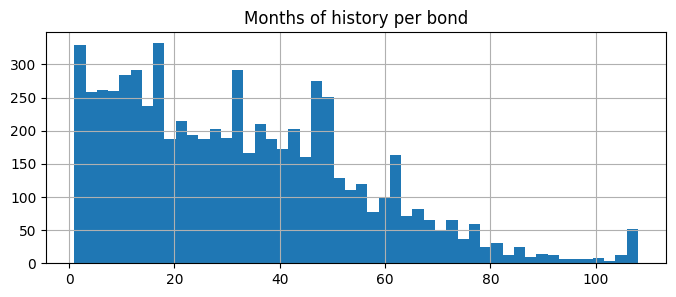

In [144]:
# A.7 — Per-bond history length
h = bonds.groupby("Cusip").Date.count()
print(h.describe(percentiles=[.05, .25, .5, .75, .95]).round(1))
print(f"\n< 6 months: {(h < 6).sum()}  |  < 12 months: {(h < 12).sum()}")
h.hist(bins=50, figsize=(8, 3))
plt.title("Months of history per bond")

In [145]:
# A.8 — Date convention: does row T's return reflect month T or month T-1?

# (a) Cross-sectional mean Total_Return vs externally-known HY index returns.
known = {
    "2011-08-01": -4.0, "2011-09-01": -3.0, "2011-10-01": +6.0,
    "2016-01-01": -1.6, "2016-03-01": +4.4, "2018-12-01": -2.1,
}
monthly = bonds.groupby("Date").Total_Return_MTD.mean()
print(f"{'Row':12} {'Ours':>8} {'External':>10}")
for d, ext in known.items():
    print(f"{d:12} {monthly[pd.Timestamp(d)]:>8.2f} {ext:>10.2f}")

# (b) HCA across EU 2011 window.
print("\nHCA mean Excess_Return by row:")
hca = bonds[bonds.Ticker == "HCA"]
for d in ["2011-07-01", "2011-08-01", "2011-10-01", "2011-11-01"]:
    print(f"  {d}: {hca[hca.Date == pd.Timestamp(d)].Excess_Return_MTD.mean():+.2f}%")

# (c) corr(Return_T, ΔOAS) — same-month vs forward-month.
b = bonds.sort_values(["Cusip", "Date"])
cur = b.OAS - b.groupby("Cusip").OAS.shift(1)
fwd = b.groupby("Cusip").OAS.shift(-1) - b.OAS
print(f"\ncorr(Return_T, OAS_T   - OAS_T-1) = {b.Excess_Return_MTD.corr(cur):+.3f}")
print(f"corr(Return_T, OAS_T+1 - OAS_T)   = {b.Excess_Return_MTD.corr(fwd):+.3f}")

Row              Ours   External
2011-08-01      -4.14      -4.00
2011-09-01      -3.00      -3.00
2011-10-01       5.30       6.00
2016-01-01      -2.83      -1.60
2016-03-01       7.62       4.40
2018-12-01      -2.32      -2.10

HCA mean Excess_Return by row:
  2011-07-01: -0.75%
  2011-08-01: -4.48%
  2011-10-01: +5.66%
  2011-11-01: -2.56%

corr(Return_T, OAS_T   - OAS_T-1) = -0.168
corr(Return_T, OAS_T+1 - OAS_T)   = +0.009


**Section A — what we learned.** Ingestion drops null OASD/DTS rows, fallen angels (BBB/A/AA), D_NR, and Class1 Government_Related / Class2 Agency. No winsorization (inverse-DTS weighting handles outliers). No minimum-history filter (would create survivorship bias). Sector cap 20%, issuer cap anchored to the 90th-percentile concentration (4) expressed as portfolio weight — exact value locked during portfolio construction. **A.8 finding:** row `YYYY-MM-01` is the end-of-month-YYYY-MM snapshot; signal inputs at row T predict return at row T+1.

## B — FRED Macro Series

In [146]:
# B.1 — FRED pull + per-series cadence. START=2000 for walk-forward warmup.
from fredapi import Fred

api_key = config.get("fred", {}).get("api_key")
assert api_key, "fred.api_key missing in config/config.yaml"
fred = Fred(api_key=api_key)

START, END = "2000-01-01", "2019-01-31"
series_ids = ["VIXCLS", "T10Y2Y", "NFCI"]
fred_raw = {s: fred.get_series(s, observation_start=START, observation_end=END) for s in series_ids}

for s, ts in fred_raw.items():
    diffs = pd.Series(ts.dropna().index).diff().dt.days.dropna()
    print(f"{s}: {len(ts):,} obs  {ts.index.min().date()} -> {ts.index.max().date()}  "
          f"nulls={ts.isnull().sum()}  median gap={diffs.median():.0f}d  max={int(diffs.max())}d")

VIXCLS: 4,979 obs  2000-01-03 -> 2019-01-31  nulls=178  median gap=1d  max=7d
T10Y2Y: 4,979 obs  2000-01-03 -> 2019-01-31  nulls=206  median gap=1d  max=4d
NFCI: 995 obs  2000-01-07 -> 2019-01-25  nulls=0  median gap=7d  max=7d


         VIXCLS    T10Y2Y     NFCI
count  4801.000  4773.000  995.000
mean     19.703     1.368   -0.321
std       8.599     0.899    0.597
min       9.140    -0.520   -0.820
5%       11.020    -0.120   -0.753
25%      13.530     0.590   -0.620
50%      17.610     1.470   -0.510
75%      23.270     2.130   -0.280
95%      35.320     2.650    0.753
max      80.860     2.910    3.060


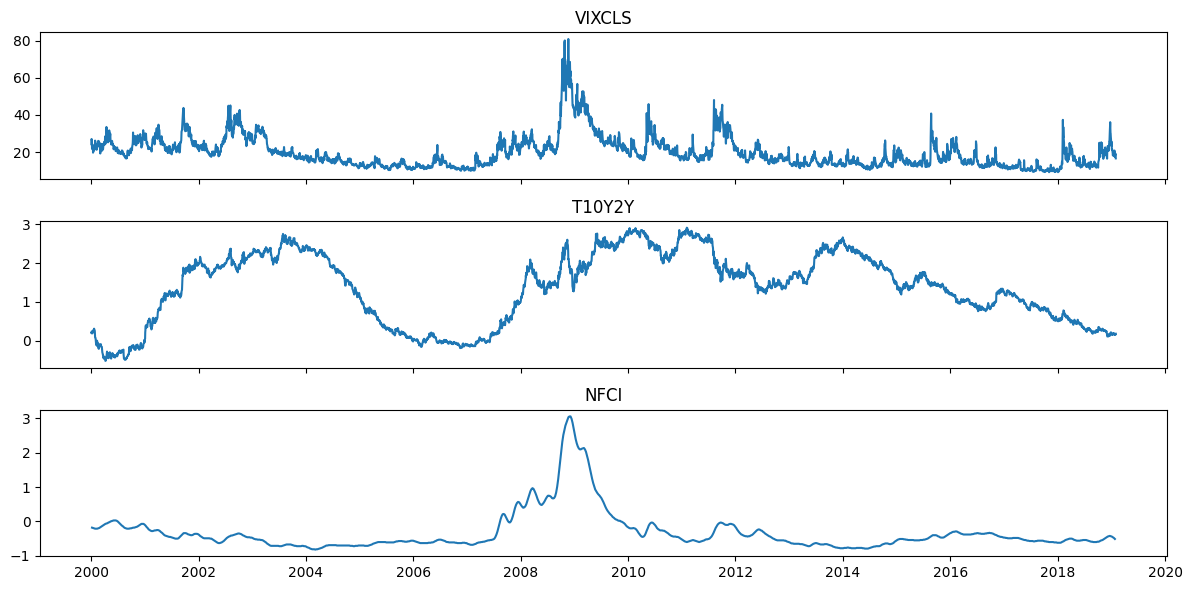

In [147]:
# B.2 — Distributions + level plot. Raw matplotlib (pandas .plot+sharex breaks on frequency mismatch).
fred_df = pd.DataFrame(fred_raw)
print(fred_df.describe(percentiles=[.05, .25, .5, .75, .95]).round(3))

fig, axes = plt.subplots(3, 1, figsize=(12, 6), sharex=True)
for ax, s in zip(axes, series_ids):
    ts = fred_raw[s].dropna()
    ax.plot(ts.index, ts.values)
    ax.set_title(s)
plt.tight_layout()

In [148]:
# B.3 — Pairwise correlations (in-sample, ffilled daily).
fred_daily = fred_df.copy().ffill()
in_sample  = fred_daily.loc["2010-01-01":"2018-12-31"]
print(in_sample.corr().round(3))

        VIXCLS  T10Y2Y   NFCI
VIXCLS   1.000   0.242  0.667
T10Y2Y   0.242   1.000 -0.016
NFCI     0.667  -0.016  1.000


In [149]:
# B.4 — In-sample 33/67 percentile cuts (vote-based reference thresholds).
print(in_sample.quantile([0.33, 0.67]).round(3))

      VIXCLS  T10Y2Y  NFCI
0.33  13.692   1.260 -0.57
0.67  17.790   1.918 -0.43


In [150]:
# B.5 — Three methods: vote-based, full-sample z-score (leakage), walk-forward z-score (production).
# Stress direction: VIX high, T10Y2Y low, NFCI high.

def pbin(s, lo, hi, stress_high=True):
    out = pd.Series(0, index=s.index)
    if stress_high:
        out[s <= lo], out[s >= hi] = +1, -1
    else:
        out[s >= hi], out[s <= lo] = +1, -1
    return out

q = in_sample.quantile([0.33, 0.67])
votes = pd.DataFrame({
    "VIXCLS": pbin(in_sample.VIXCLS, q.VIXCLS[0.33], q.VIXCLS[0.67], True),
    "T10Y2Y": pbin(in_sample.T10Y2Y, q.T10Y2Y[0.33], q.T10Y2Y[0.67], False),
    "NFCI":   pbin(in_sample.NFCI,   q.NFCI[0.33],   q.NFCI[0.67],   True),
})
regime_vote = pd.cut(votes.sum(axis=1), bins=[-3.5, -1.5, 1.5, 3.5], labels=["risk_off", "neutral", "risk_on"])

# Full-sample z-score (leakage; viz only)
z = (in_sample - in_sample.mean()) / in_sample.std()
comp_full = pd.DataFrame({"VIXCLS": z.VIXCLS, "T10Y2Y": -z.T10Y2Y, "NFCI": z.NFCI}).mean(axis=1)
regime_zfull = pd.cut(comp_full, bins=[-np.inf, comp_full.quantile(0.33), comp_full.quantile(0.67), np.inf],
                      labels=["risk_on", "neutral", "risk_off"])

# Walk-forward z-score (production)
fred_monthly = fred_daily.resample("M").last()
tmean = fred_monthly.shift(1).rolling(60, min_periods=24).mean()
tstd  = fred_monthly.shift(1).rolling(60, min_periods=24).std()
zw = (fred_monthly - tmean) / tstd
comp_walk = pd.DataFrame({"VIXCLS": zw.VIXCLS, "T10Y2Y": -zw.T10Y2Y, "NFCI": zw.NFCI}).mean(axis=1)

pretrain = comp_walk.loc[:"2009-12-31"].dropna()
thresh_low, thresh_high = pretrain.quantile([0.33, 0.67])
print(f"Walk-forward pre-2010 thresholds: 33%={thresh_low:.3f}  67%={thresh_high:.3f}  (n={len(pretrain)})")

regime_walk = pd.cut(comp_walk, bins=[-np.inf, thresh_low, thresh_high, np.inf],
                     labels=["risk_on", "neutral", "risk_off"])
regime_walk_bt = regime_walk.loc["2010-01-01":"2018-12-31"].dropna()

print("\nRegime frequency (%) on 2010-2018:")
print(f"  Vote-based:     {dict((regime_vote.value_counts(normalize=True)*100).round(1))}")
print(f"  Full-sample z:  {dict((regime_zfull.value_counts(normalize=True)*100).round(1))}")
print(f"  Walk-forward z: {dict((regime_walk_bt.value_counts(normalize=True)*100).round(1))}")

agree = (regime_walk.reindex(regime_zfull.index, method="ffill").astype(str) == regime_zfull.astype(str)).mean()
print(f"\nAgreement walk-forward vs full-sample: {agree:.3f}")

Walk-forward pre-2010 thresholds: 33%=-0.548  67%=0.249  (n=96)

Regime frequency (%) on 2010-2018:
  Vote-based:     {'neutral': np.float64(60.7), 'risk_off': np.float64(19.9), 'risk_on': np.float64(19.4)}
  Full-sample z:  {'neutral': np.float64(34.0), 'risk_on': np.float64(33.0), 'risk_off': np.float64(33.0)}
  Walk-forward z: {'neutral': np.float64(47.2), 'risk_off': np.float64(26.9), 'risk_on': np.float64(25.9)}

Agreement walk-forward vs full-sample: 0.620


C:\Users\Sam\AppData\Local\Temp\ipykernel_30840\1464344798.py:27: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  fred_monthly = fred_daily.resample("M").last()


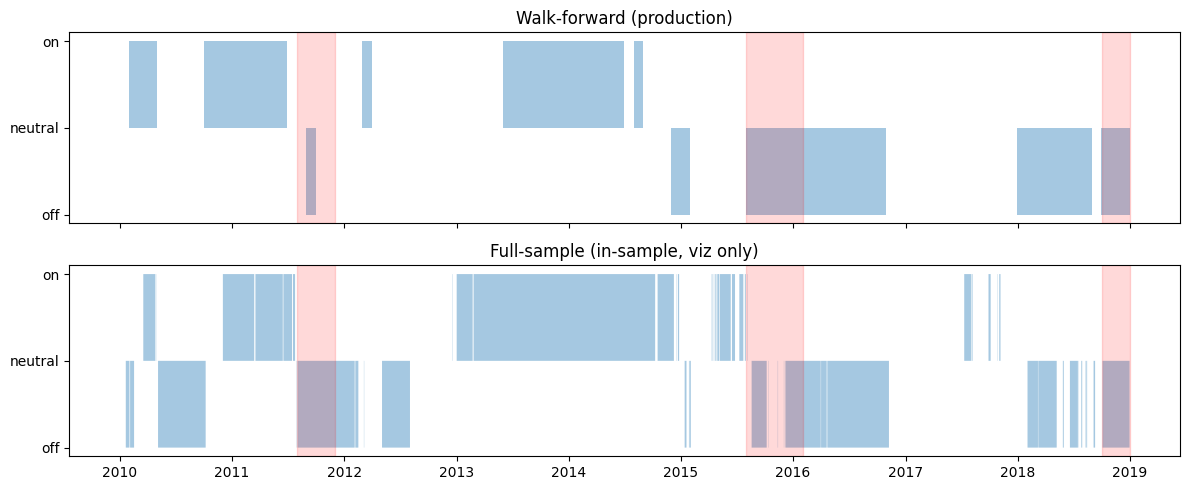

In [151]:
# B.6 — Regime timelines: walk-forward (production) vs full-sample (in-sample, viz). Red = known stress.
fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
stress = [("2011-08-01", "2011-12-01"), ("2015-08-01", "2016-02-01"), ("2018-10-01", "2018-12-31")]

for ax, reg, title in [
    (axes[0], regime_walk.loc["2010-01-01":"2018-12-31"], "Walk-forward (production)"),
    (axes[1], regime_zfull,                                "Full-sample (in-sample, viz only)"),
]:
    c = reg.map({"risk_on": 1, "neutral": 0, "risk_off": -1}).astype(float)
    ax.fill_between(c.index, c.values, alpha=0.4, step="pre")
    ax.set_yticks([-1, 0, 1])
    ax.set_yticklabels(["off", "neutral", "on"])
    ax.set_title(title)
    for s, e in stress:
        ax.axvspan(pd.Timestamp(s), pd.Timestamp(e), alpha=0.15, color="red")
plt.tight_layout()

**Section B — what we learned.** Locked: walk-forward composite z-score (60-month rolling, monthly cadence; thresholds fit on pre-2010 composites — out-of-sample for backtest). Vote-based rejected — 61% neutral, insufficient resolution. Full-sample z-score rejected — in-sample leakage; retained in B.6 as visualization. 100/66/33 allocation pending B.6 visual review.

## C — Point-in-Time Join Sanity

In [152]:
# C.1 — PIT join: bond row T pairs with FRED date <= end_of_month(T) (row T = end-of-T snapshot, per A.8).
sample = [pd.Timestamp("2010-01-01"), pd.Timestamp("2011-08-01"), pd.Timestamp("2018-12-01")]
rows = []
for d in sample:
    cutoff = d + pd.offsets.MonthEnd(0)
    row = {"bond_label": d.date(), "snapshot_asof": cutoff.date()}
    for s, ts in fred_raw.items():
        before = ts[ts.index <= cutoff].dropna()
        last = before.index.max()
        row[f"{s}_value"] = round(float(before.iloc[-1]), 3)
        row[f"{s}_asof"]  = last.date()
        row[f"{s}_lag_d"] = (cutoff - last).days
    rows.append(row)
print(pd.DataFrame(rows).to_string(index=False))

bond_label snapshot_asof  VIXCLS_value VIXCLS_asof  VIXCLS_lag_d  T10Y2Y_value T10Y2Y_asof  T10Y2Y_lag_d  NFCI_value  NFCI_asof  NFCI_lag_d
2010-01-01    2010-01-31         24.62  2010-01-29             2          2.81  2010-01-29             2       -0.20 2010-01-29           2
2011-08-01    2011-08-31         31.62  2011-08-31             0          2.03  2011-08-31             0       -0.14 2011-08-26           5
2018-12-01    2018-12-31         25.42  2018-12-31             0          0.21  2018-12-31             0       -0.43 2018-12-28           3


**Section C — what we learned.** PIT join: bond row T pairs with FRED date ≤ `end_of_month(T)`. Lag at month-end: VIX/T10Y2Y 0d, NFCI 0–6d.